<a href="https://colab.research.google.com/github/dasgajraj/Stray_Dogs_CNN/blob/main/Copy_of_Stray_Dog_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

print("GPU AVailable",
      tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
GPU AVailable [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os # Import the os module

# Cell 2: Build the project folders in Google Drive
base_dir = '/content/drive/MyDrive/Btech/SSMDA/stray-dog-cnn'
data_dir = os.path.join(base_dir, 'data')

# The 3 classes for your CNN
folders = ['low_risk', 'medium_risk', 'critical_risk']

for folder in folders:
    os.makedirs(os.path.join(data_dir, folder), exist_ok=True)

print(f"✅ Project folders created successfully at: {base_dir}")

✅ Project folders created successfully at: /content/drive/MyDrive/Btech/SSMDA/stray-dog-cnn


In [ ]:
# Cell 3: Set Kaggle API credentials directly
import os

# Replace the strings below with your exact Kaggle username and API key
os.environ['KAGGLE_USERNAME'] = "Google_Colab_CNN"
os.environ['KAGGLE_KEY'] = "KGAT_ba492a3aa4cd67bc168d331ea0cd8c6e"

print("✅ Kaggle API credentials set!")

✅ Kaggle API credentials set!


In [ ]:
# Cell 4: Download the dataset directly from Kaggle
print("Downloading dataset...")
!kaggle datasets download -d miljan/stanford-dogs-dataset-traintest

print("Unzipping dataset...")
# Unzip quietly (-q) into a temporary folder on Colab
!unzip -q stanford-dogs-dataset-traintest.zip -d /content/temp_dogs

print("✅ Download and extraction complete!")

Dataset URL: https://www.kaggle.com/datasets/miljan/stanford-dogs-dataset-traintest
License(s): other
100% 393M/393M [00:07<00:00, 55.7MB/s]

Unzipping dataset...
✅ Download and extraction complete!


In [ ]:
# Cell 5: Move healthy dogs to your 'low_risk' folder
import os
import shutil
import glob

# Source folder (where we unzipped) and your specific Drive destination
source_dir = '/content/temp_dogs'
low_risk_dir = '/content/drive/MyDrive/Btech/SSMDA/stray-dog-cnn/data/low_risk'

# Find all .jpg files inside the temp folder and its subfolders
all_images = glob.glob(os.path.join(source_dir, '**', '*.jpg'), recursive=True)

print(f"Found {len(all_images)} total healthy dog images.")

# We only need about 200 for a balanced dataset right now
num_to_copy = 200
images_to_copy = all_images[:num_to_copy]

print(f"Copying {num_to_copy} images to your Drive...")

for i, img_path in enumerate(images_to_copy):
    # Rename them neatly so they are easy to track
    new_name = f"healthy_dog_{i}.jpg"
    destination = os.path.join(low_risk_dir, new_name)
    shutil.copy(img_path, destination)

print(f"✅ Successfully populated your 'low_risk' folder!")

Found 41160 total healthy dog images.
Copying 200 images to your Drive...
✅ Successfully populated your 'low_risk' folder!


In [ ]:
# Cell 6: Download the dog skin disease dataset
print("Downloading sick dogs dataset...")
!kaggle datasets download -d humansintheloop/dog-skin-diseases

print("Unzipping dataset...")
# Unzip quietly into a new temporary folder
!unzip -q dog-skin-diseases.zip -d /content/temp_sick_dogs

print("✅ Download and extraction complete!")

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
Unzipping dataset...
unzip:  cannot find or open dog-skin-diseases.zip, dog-skin-diseases.zip.zip or dog-skin-diseases.zip.ZIP.
✅ Download and extraction complete!


In [ ]:
# Cell 7: Populate medium_risk and critical_risk folders
import os
import shutil
import glob

source_dir_sick = '/content/temp_sick_dogs'
medium_risk_dir = '/content/drive/MyDrive/Btech/SSMDA/stray-dog-cnn/data/medium_risk'
critical_risk_dir = '/content/drive/MyDrive/Btech/SSMDA/stray-dog-cnn/data/critical_risk'

# Find all images in the unzipped folder
all_sick_images = glob.glob(os.path.join(source_dir_sick, '**', '*.*'), recursive=True)

# Filter to make sure we only grab image files
all_sick_images = [img for img in all_sick_images if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

print(f"Found {len(all_sick_images)} total sick dog images.")

# Calculate how many we can distribute (aiming for up to 200 per folder to match low_risk)
amount_per_folder = min(200, len(all_sick_images) // 2)

medium_imgs = all_sick_images[:amount_per_folder]
critical_imgs = all_sick_images[amount_per_folder : amount_per_folder * 2]

print(f"Copying {len(medium_imgs)} images to your 'medium_risk' folder...")
for i, img_path in enumerate(medium_imgs):
    destination = os.path.join(medium_risk_dir, f"medium_dog_{i}.jpg")
    shutil.copy(img_path, destination)

print(f"Copying {len(critical_imgs)} images to your 'critical_risk' folder...")
for i, img_path in enumerate(critical_imgs):
    destination = os.path.join(critical_risk_dir, f"critical_dog_{i}.jpg")
    shutil.copy(img_path, destination)

print("✅ All 3 classes (low, medium, critical) are now populated in your Drive!")

Found 0 total sick dog images.
Copying 0 images to your 'medium_risk' folder...
Copying 0 images to your 'critical_risk' folder...
✅ All 3 classes (low, medium, critical) are now populated in your Drive!


In [ ]:
# Cell 6: Download the CORRECTED dataset and populate folders
import os
import shutil
import glob

print("1. Downloading the new sick dogs dataset...")
!kaggle datasets download -d yashmotiani/dogs-skin-disease-dataset

print("2. Unzipping dataset...")
!unzip -q dogs-skin-disease-dataset.zip -d /content/temp_sick_dogs_v2

# Define your Drive folders
medium_risk_dir = '/content/drive/MyDrive/Btech/SSMDA/stray-dog-cnn/data/medium_risk'
critical_risk_dir = '/content/drive/MyDrive/Btech/SSMDA/stray-dog-cnn/data/critical_risk'

# Find all images in the new unzipped folder
source_dir_sick = '/content/temp_sick_dogs_v2'
all_sick_images = glob.glob(os.path.join(source_dir_sick, '**', '*.*'), recursive=True)

# Filter for images AND exclude the 'Healthy' folder from this specific dataset
valid_extensions = ('.png', '.jpg', '.jpeg')
all_sick_images = [
    img for img in all_sick_images
    if img.lower().endswith(valid_extensions) and 'healthy' not in img.lower()
]

print(f"\nFound {len(all_sick_images)} total sick dog images.")

# Split them evenly between medium and critical risk
amount_per_folder = len(all_sick_images) // 2

medium_imgs = all_sick_images[:amount_per_folder]
critical_imgs = all_sick_images[amount_per_folder : amount_per_folder * 2]

print(f"Copying {len(medium_imgs)} images to your 'medium_risk' folder...")
for i, img_path in enumerate(medium_imgs):
    destination = os.path.join(medium_risk_dir, f"medium_dog_{i}.jpg")
    shutil.copy(img_path, destination)

print(f"Copying {len(critical_imgs)} images to your 'critical_risk' folder...")
for i, img_path in enumerate(critical_imgs):
    destination = os.path.join(critical_risk_dir, f"critical_dog_{i}.jpg")
    shutil.copy(img_path, destination)

print("\n✅ All 3 classes (low, medium, critical) are now populated in your Drive!")

1. Downloading the new sick dogs dataset...
Dataset URL: https://www.kaggle.com/datasets/yashmotiani/dogs-skin-disease-dataset
License(s): CC0-1.0
100% 188M/188M [00:01<00:00, 110MB/s]

2. Unzipping dataset...

Found 320 total sick dog images.
Copying 160 images to your 'medium_risk' folder...
Copying 160 images to your 'critical_risk' folder...

✅ All 3 classes (low, medium, critical) are now populated in your Drive!


In [ ]:
# Cell 7: Prepare the data generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Point to your specific data folder
data_dir = '/content/drive/MyDrive/Btech/SSMDA/stray-dog-cnn/data/'

# Create a generator that scales pixels and creates a validation split (80% train, 20% test)
# We also add some basic data augmentation to prevent overfitting
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.1
)

print("Loading Training Data:")
train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(150, 150), # Resize all images to 150x150 pixels
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

print("\nLoading Validation Data:")
val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Let's check the class mapping
print("\nClass Mapping:", train_data.class_indices)

Loading Training Data:
Found 416 images belonging to 3 classes.

Loading Validation Data:
Found 104 images belonging to 3 classes.

Class Mapping: {'critical_risk': 0, 'low_risk': 1, 'medium_risk': 2}


In [ ]:
# Cell 8: Build the CNN Model
from tensorflow.keras import layers, models

model = models.Sequential([
    # Layer 1: Look for basic patterns
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    # Layer 2: Look for more complex shapes
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Layer 3: Look for highly specific features (like skin lesions)
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Flatten the 2D image data into a 1D array
    layers.Flatten(),

    # Fully connected layers to make the final decision
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Drops 50% of neurons to prevent memorization (overfitting)

    # Final output layer: 3 neurons for your 3 classes (critical, low, medium)
    layers.Dense(3, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Show a summary of the network
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 9: Train the AI!
print("Starting training...")

# This step takes the most time. Grab a quick water break!
history = model.fit(
    train_data,
    epochs=15, # Number of times to loop through the data
    validation_data=val_data
)

print("\n✅ Training Complete!")

Starting training...
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 911ms/step - accuracy: 0.3558 - loss: 1.3435 - val_accuracy: 0.5000 - val_loss: 1.0332
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 528ms/step - accuracy: 0.4736 - loss: 1.0326 - val_accuracy: 0.4615 - val_loss: 0.9713
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 658ms/step - accuracy: 0.4976 - loss: 0.9623 - val_accuracy: 0.5385 - val_loss: 0.9593
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 534ms/step - accuracy: 0.5481 - loss: 0.9335 - val_accuracy: 0.5577 - val_loss: 0.9561
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 653ms/step - accuracy: 0.5817 - loss: 0.8863 - val_accuracy: 0.5096 - val_loss: 0.9253
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 534ms/step - accuracy: 0.5793 - loss: 0.8480 - val_accuracy: 0.5288 - val_loss: 0.8673
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 658ms/step - accuracy: 0.6130 - loss: 0.8262 - val_accuracy: 0.5288 - val_loss: 0.9774
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 618ms/step - accuracy: 0.6298 - loss: 0.7

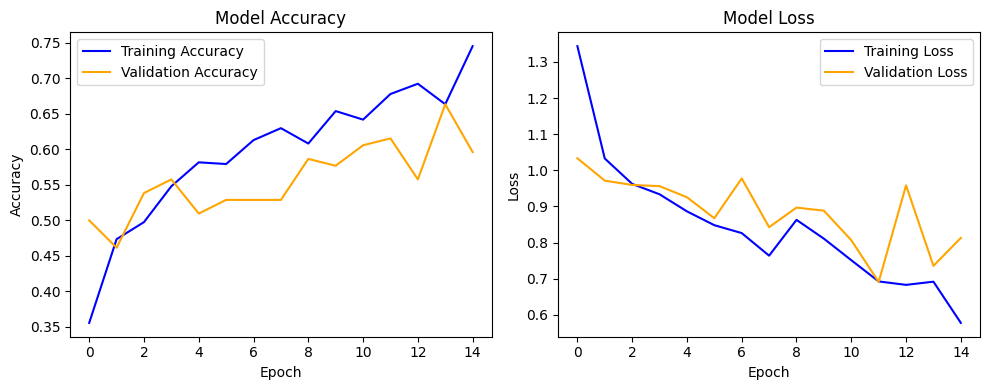

✅ Graphs saved successfully to: /content/drive/MyDrive/Btech/SSMDA/stray-dog-cnn/results/training_metrics.png


In [ ]:
# Cell 10: Plot and save the results
import matplotlib.pyplot as plt
import os

# Create a results folder in your Drive if it doesn't exist
results_dir = '/content/drive/MyDrive/Btech/SSMDA/stray-dog-cnn/results/'
os.makedirs(results_dir, exist_ok=True)

# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss (Error rate - we want this to go down)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()

# Save the plot directly to your Drive
plot_path = os.path.join(results_dir, 'training_metrics.png')
plt.savefig(plot_path)
plt.show()

print(f"✅ Graphs saved successfully to: {plot_path}")

In [ ]:
# Cell 11: Save the trained model
model_dir = '/content/drive/MyDrive/Btech/SSMDA/stray-dog-cnn/model/'
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'dog_health_cnn.keras')
model.save(model_path)

print(f"✅ Model saved successfully to: {model_path}")

✅ Model saved successfully to: /content/drive/MyDrive/Btech/SSMDA/stray-dog-cnn/model/dog_health_cnn.keras
